<a href="https://colab.research.google.com/github/miriampaul/ML-Classification-Model/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Logistic Regression is a classification technique used to predict the probability of a binary(true/false) outcome

In its simplest form, logistic regression forms an **S - shaped (sigmoid) **curve between 0 and 1 , which represents the probability of a TRUE outcome for any given value of Z.

The likelihood function mneasures how accurately a model predicts outcomes, and is used to optimize the 'shape' of the curve.


**Example use cases:**
Flaggin spam emails or fraud credit card transactions

Determining whether to serve a particular ad to a website visitor



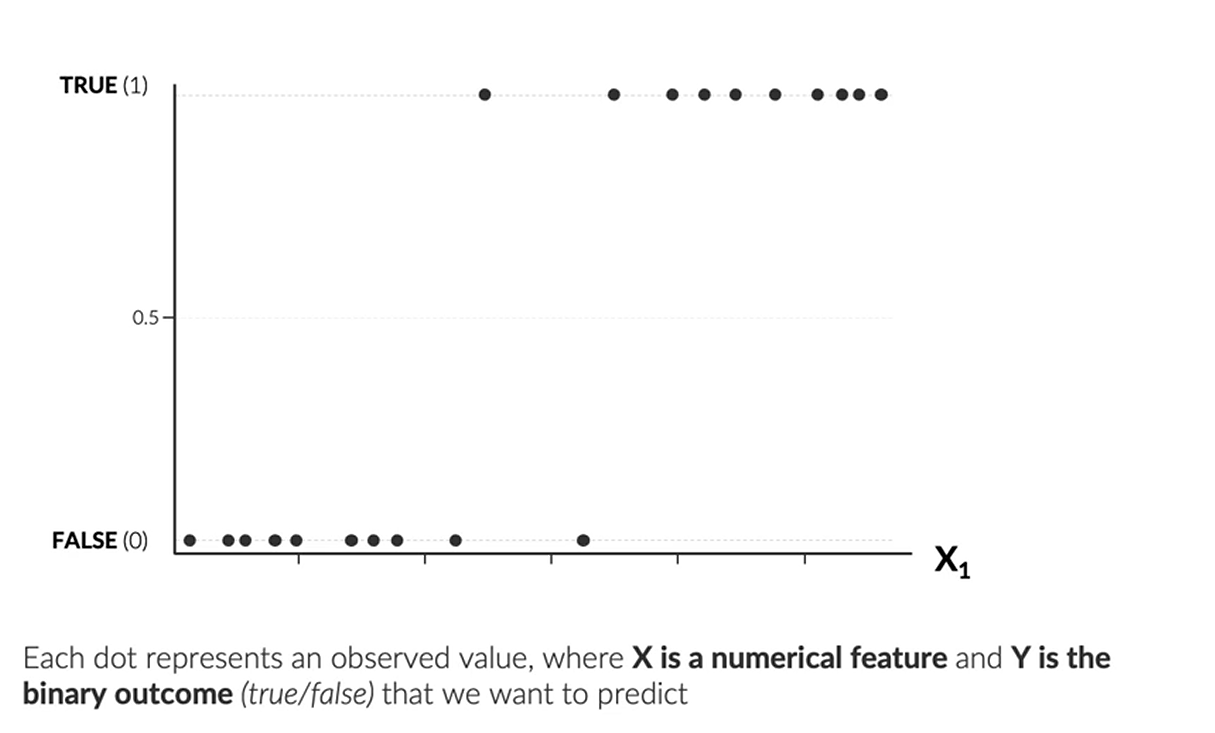

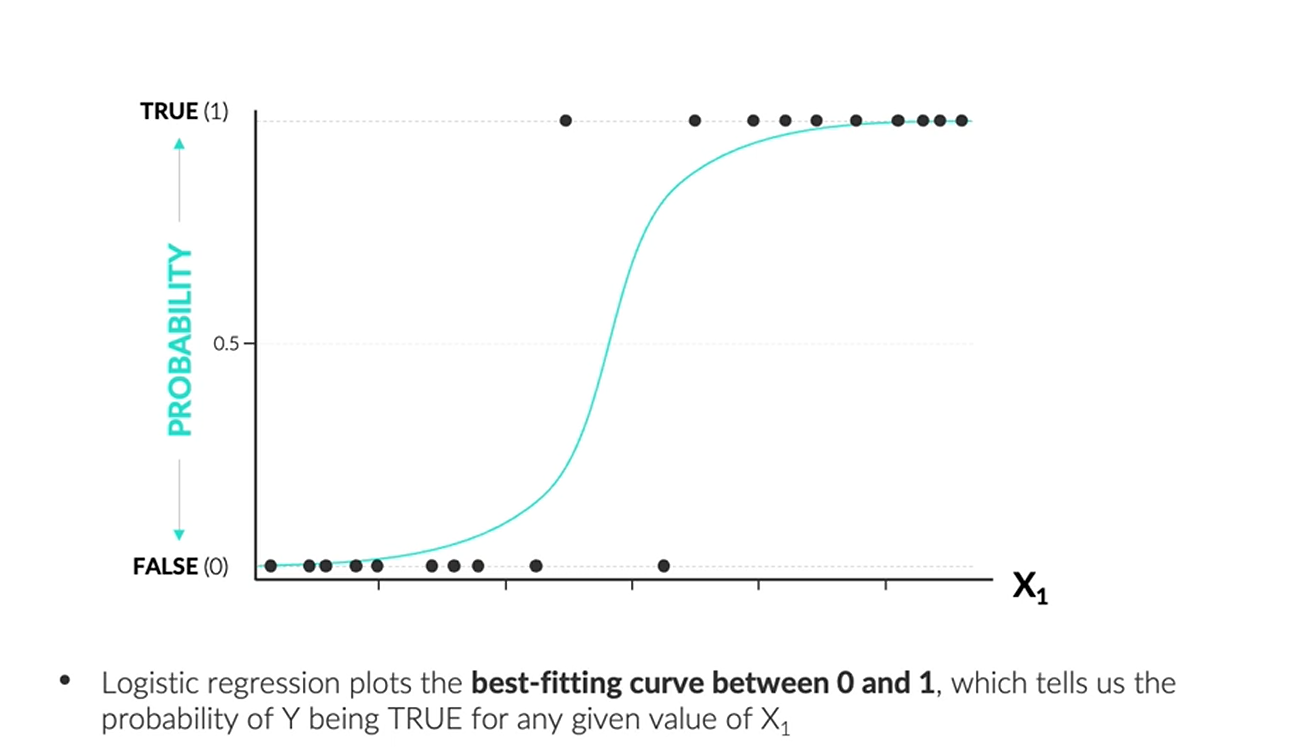

Logistic Regression and Linear Regression are both linear models but logistic regression outputs probability , which is bounded by 0 and 1 .

The logit transformation helps convert linear model outputs to probabilities

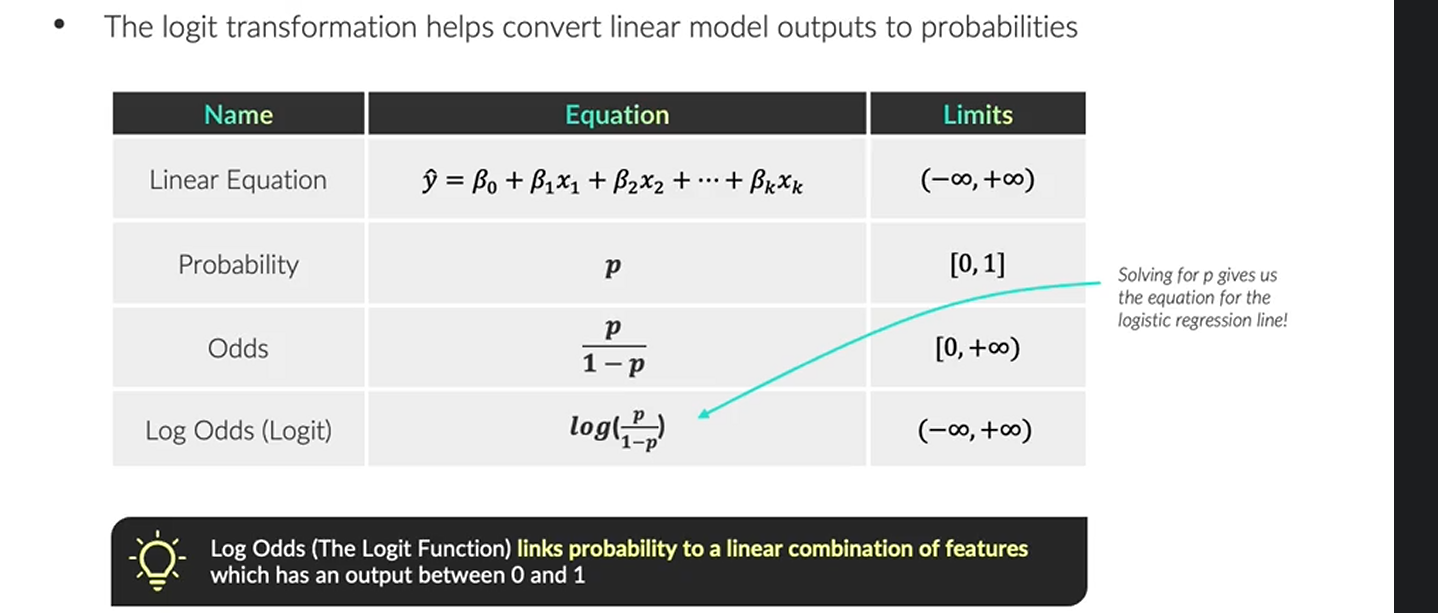

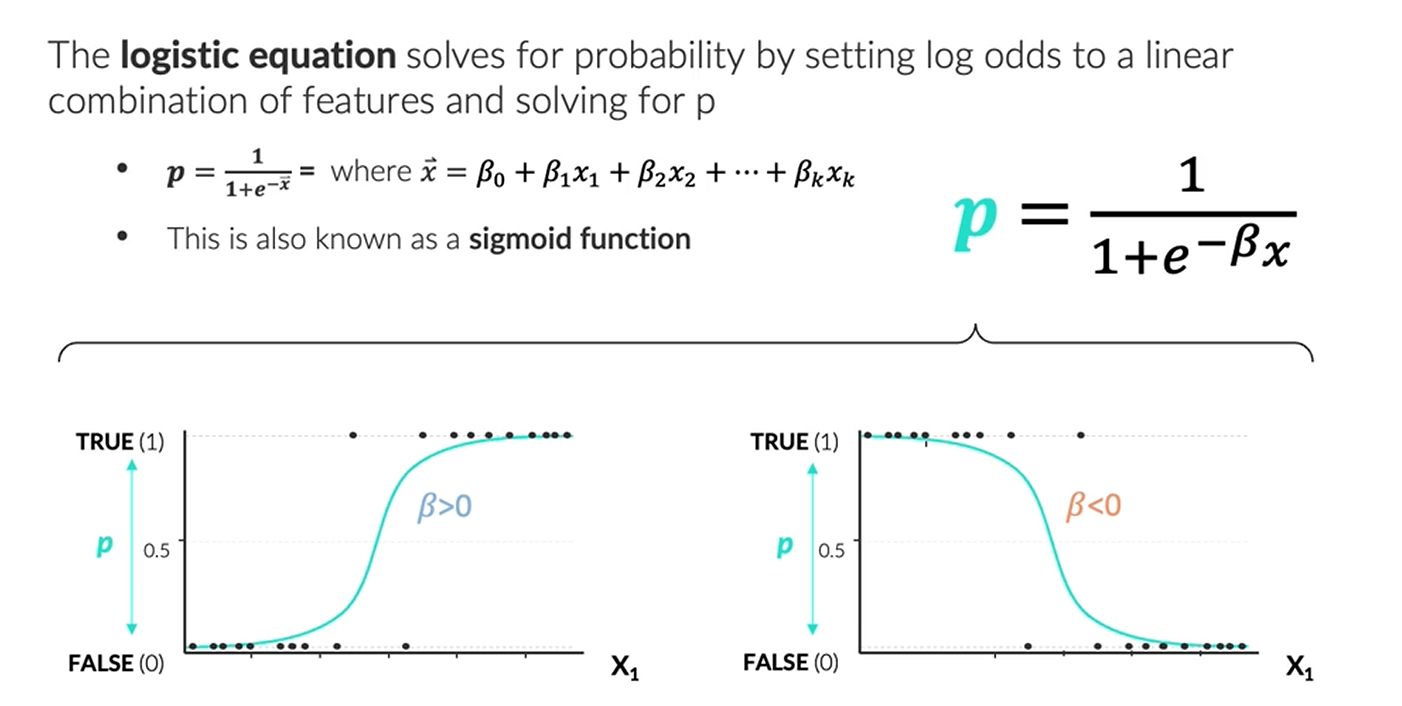

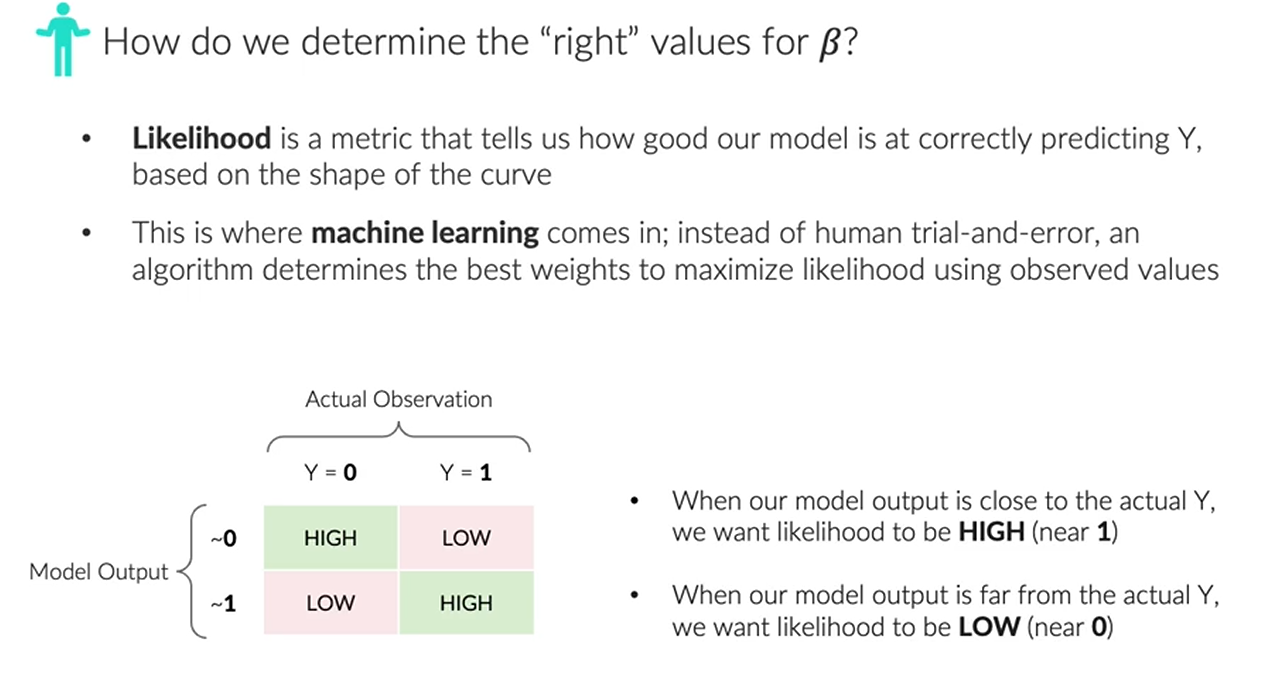

How do we detrermine the right value for Beta.

Likelihood is a metric that tells us how good our model is at predicting Y.  Based on the shape of the curve.


This is where ML comes in, Instead of human trial and error, a alogrithm determines the best weights to maximize the likelihood using observed values.



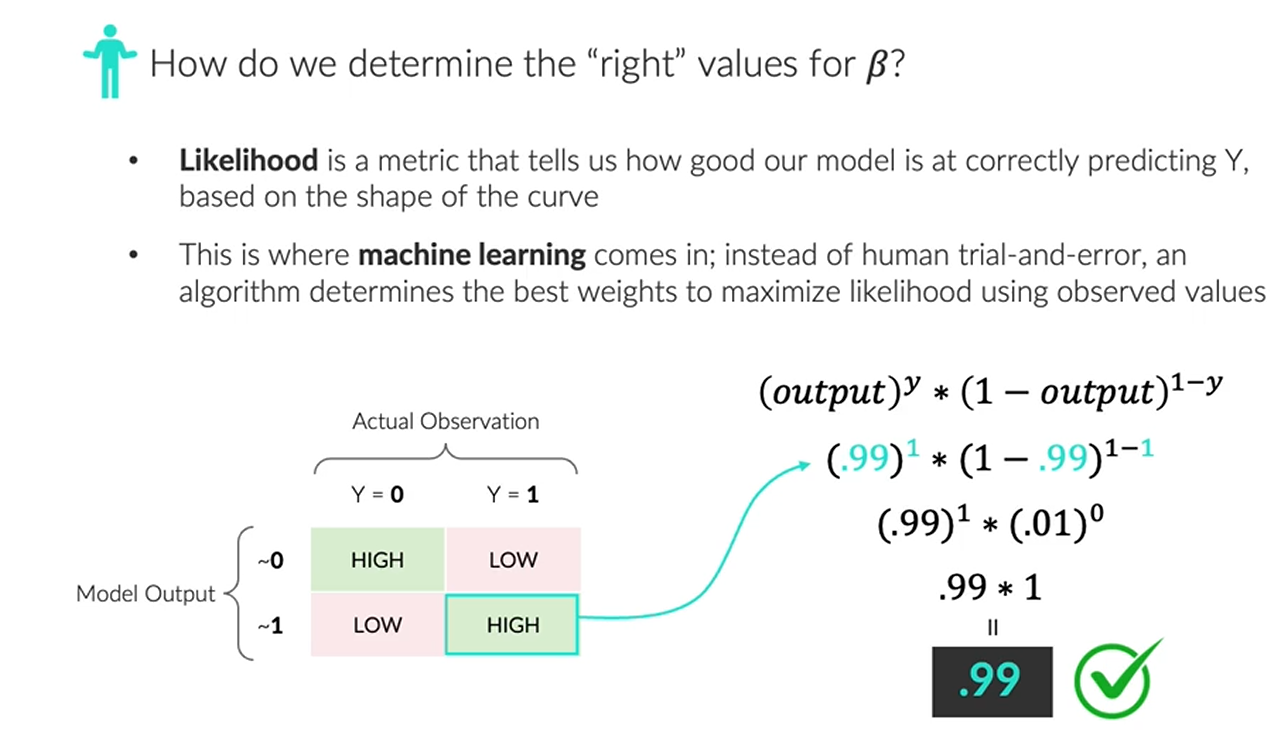

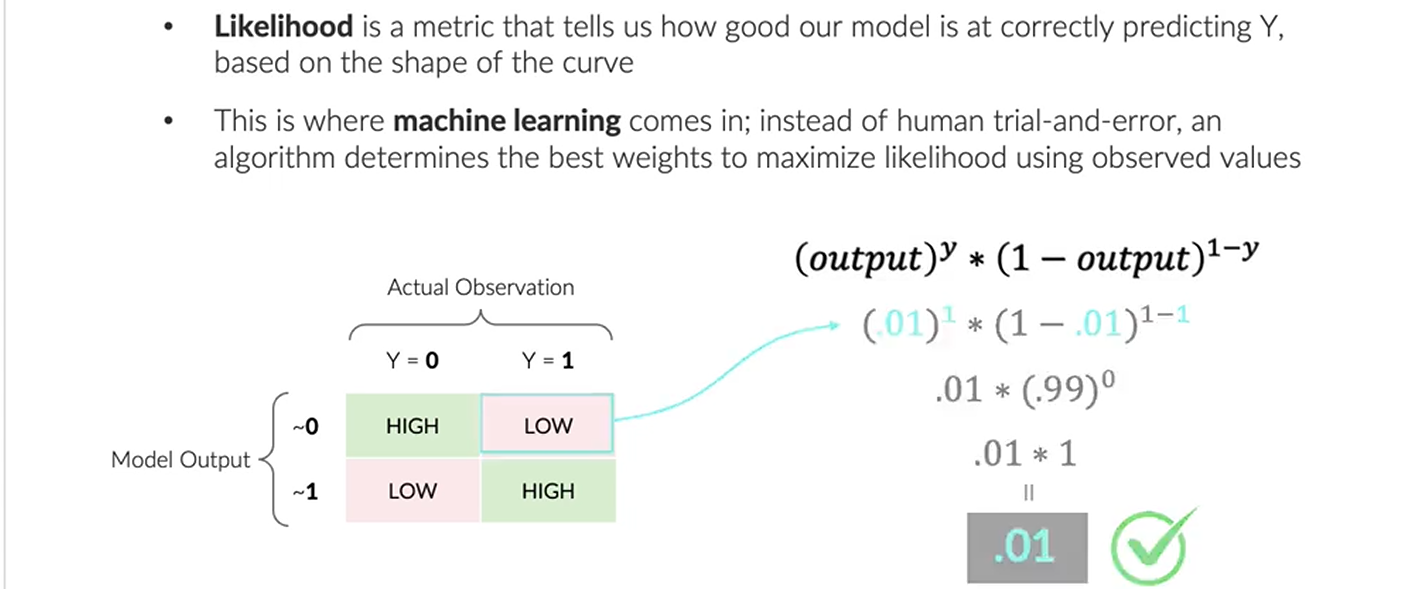

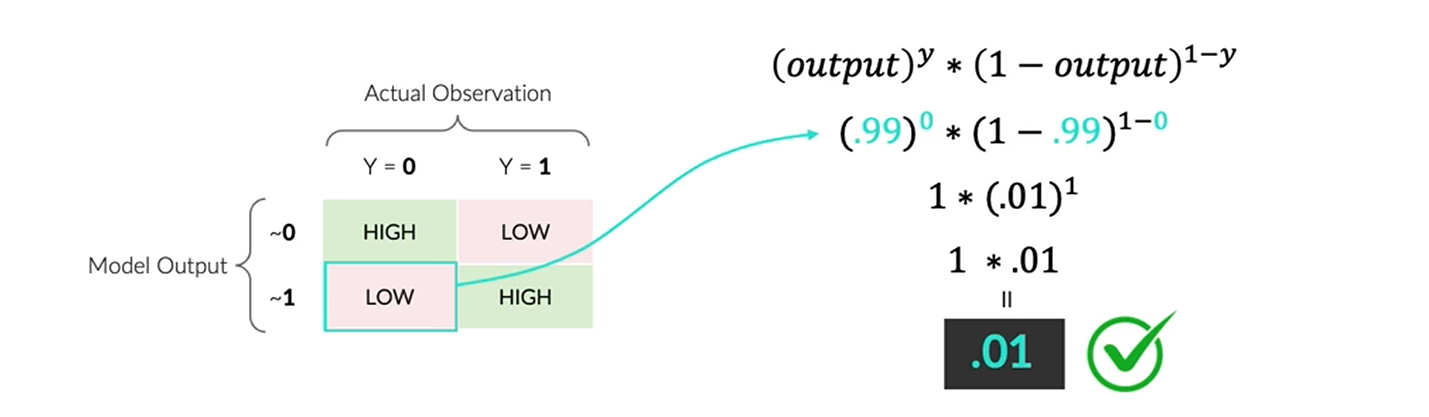

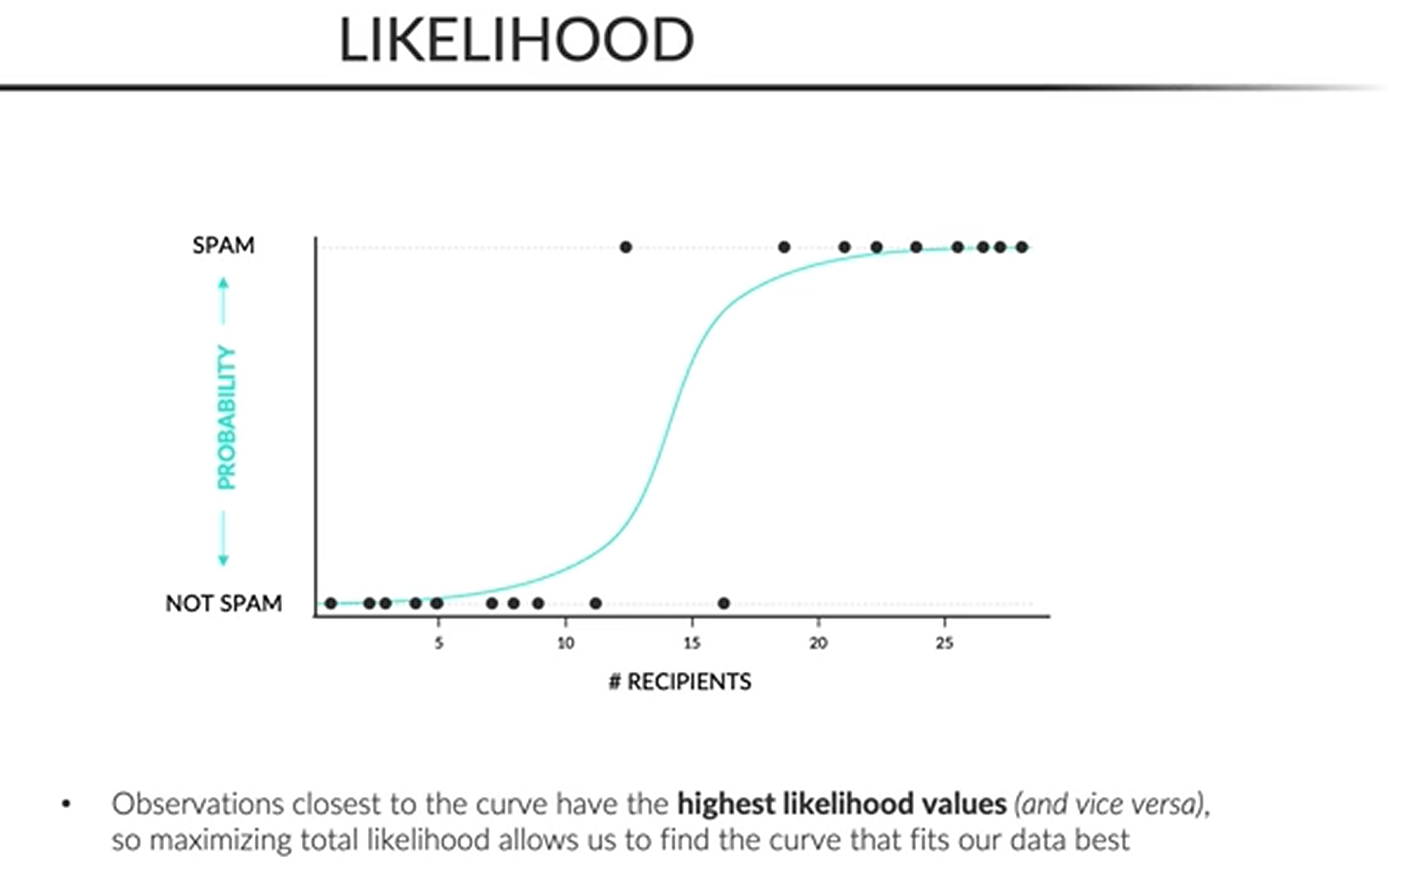

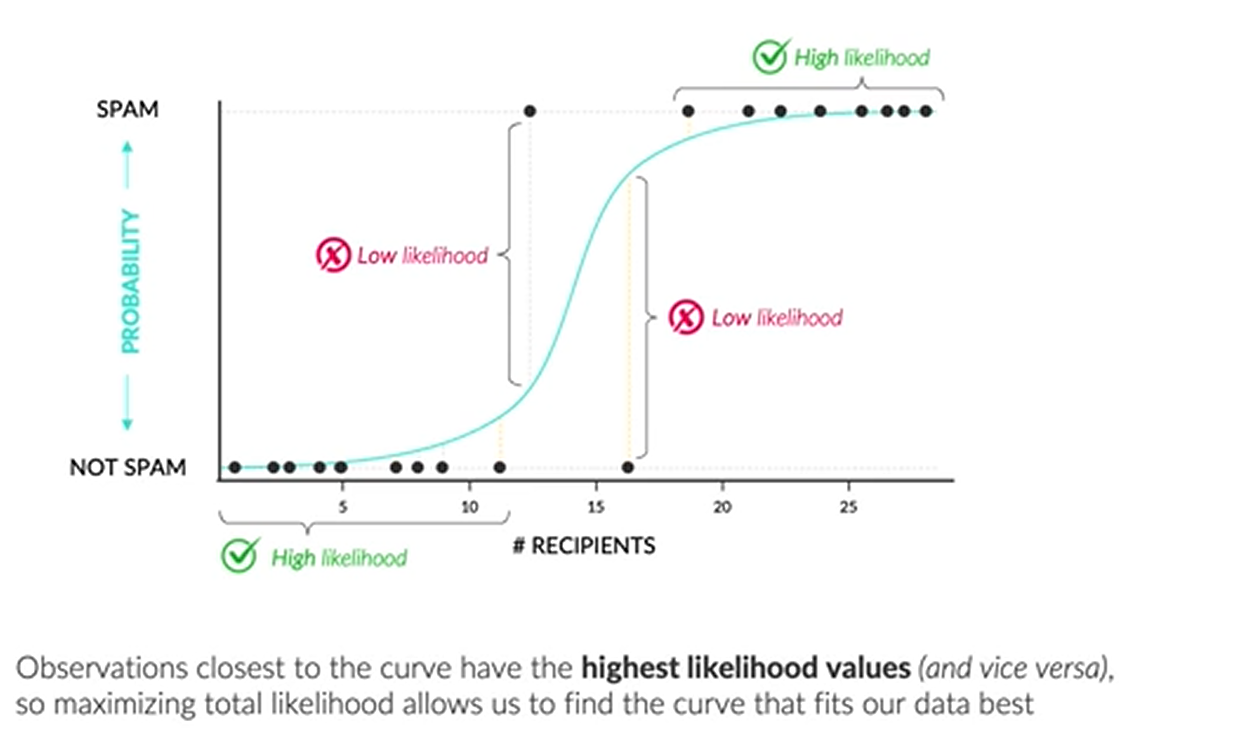

**Multiple logistic Regression**

What if multiple X variables could help predict Y?


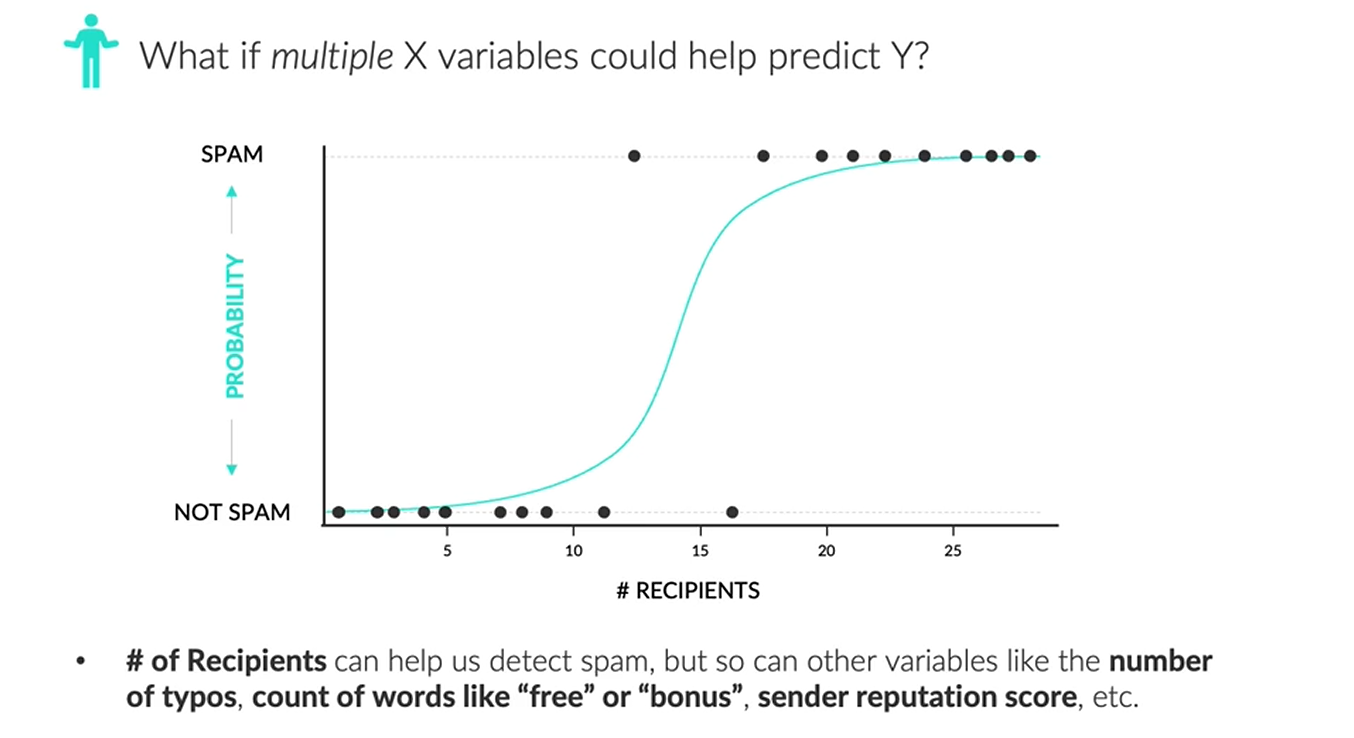





Logistic regression is about finding the best combination of weights (b1, b1, bn) for a given set features(x1,x2,xn) to maximize the likelihood function.



> Add blockquote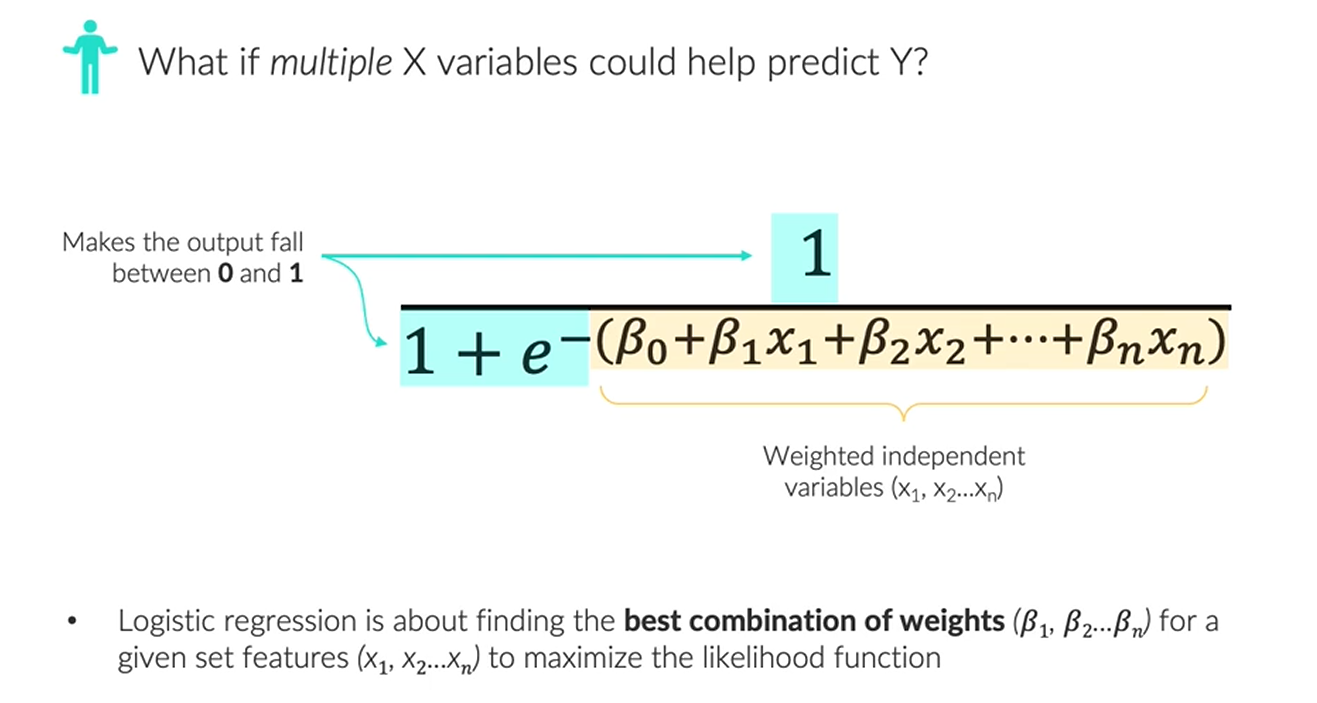



In python you can fit a logistic refression model using the scikit-learn library.

Sklearn . linear_model.LogisticRegression()

Model.coef_ and model.intercept_ return the fitted coeff and intercept


In [ ]:
# from sklearn.linear_model import LogisticRegression
# logreg=LogisticRegression()
# lr=logreg.fit(X_train, y_train)

In Python you can fit a logistic regression model using the scikit-learn library

Model.score(X, y) returns an accuracy score for a given set of features and target values

Confusion matrix(y_actual, y_pred) returns a confusion matrix



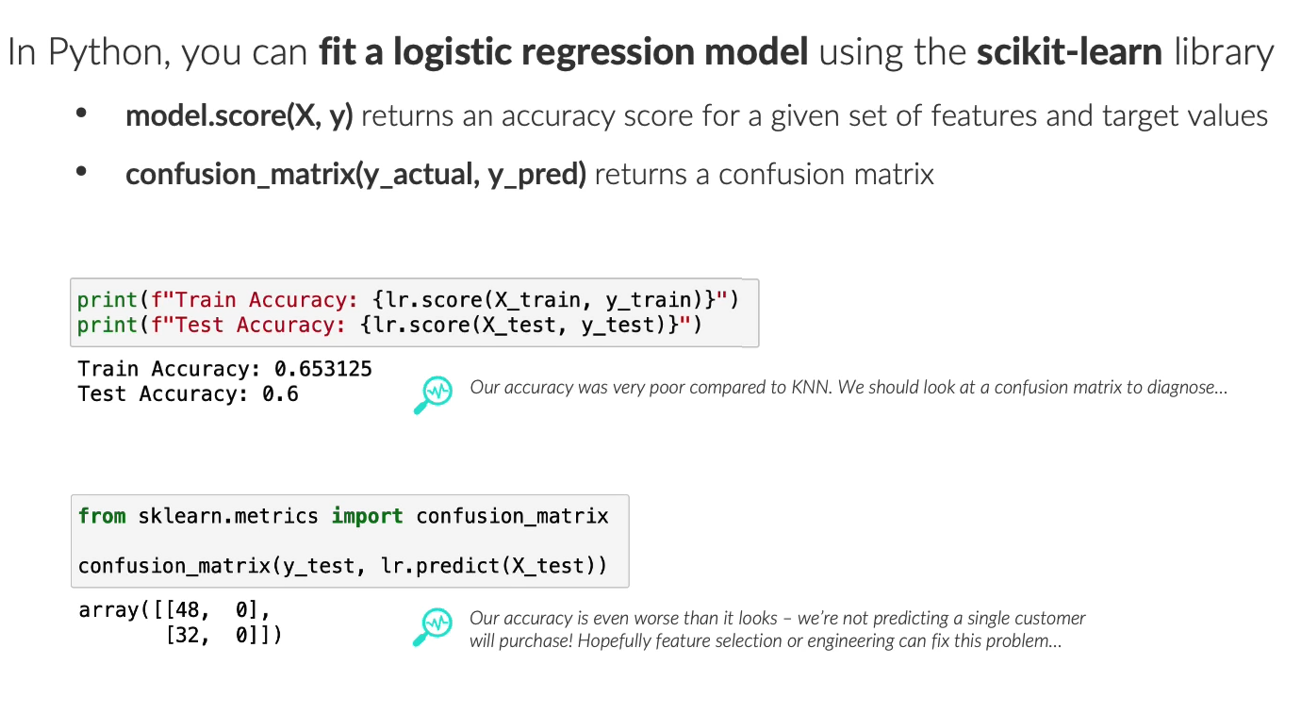

In [ ]:
import pandas as pd

In [ ]:
DS=pd.read_csv('/content/ds (1).csv')

In [ ]:
SV=pd.read_csv("/content/sv (1).csv")

In [ ]:
DS=DS[['USUBJID','DSDECOD','DSCAT','DSSTDTC']]

In [ ]:
DM=pd.read_csv('/content/dm (1).csv')

In [ ]:

DS_filtered = DS[
    (~DS['DSDECOD'].isin(['DEATH', 'COMPLETED', 'SCREEN FAILURE', 'SCREENFAILURE', " "])) &
    (DS['DSCAT'].isin(['DISPOSITION EVENT']))
]

In [ ]:
DM=DM[['USUBJID','ARM','SITEID']]

In [ ]:
DM_filtered = DM[DM['ARM'].str.contains('Placebo', case=False)]

In [ ]:
DM_filtered

,USUBJID,ARM,SITEID
0,01-701-1015,Placebo,701
1,01-701-1023,Placebo,701
5,01-701-1047,Placebo,701
10,01-701-1118,Placebo,701
11,01-701-1130,Placebo,701
...,...,...,...
290,01-717-1344,Placebo,717
296,01-718-1139,Placebo,718
297,01-718-1150,Placebo,718
299,01-718-1172,Placebo,718


In [ ]:
DS_DM=pd.merge(DM_filtered, DS_filtered, on='USUBJID', how='inner')

In [ ]:
#Now let us create an if else condition to flag these subjects before we merge it into a final table containing all subjects
DS_DM['cp_control_arm'] = DS_DM['USUBJID'].apply(lambda x: 'Y' if pd.notna(x) else None)
DS_DM['cp_control_flag'] = DS_DM['USUBJID'].apply(lambda x: 1 if pd.notna(x) else None)

In [ ]:
import numpy as np

def add_cp_flags(df):
  df['cp_control_arm'] = np.where(df['USUBJID'].notna(), 'Y', 'N')
  df['cp_control_flag'] = np.where(df['USUBJID'].notna(), 1, 0)
  return df

DS_DM = add_cp_flags(DS_DM)

In [ ]:
SV=SV[['USUBJID','VISIT','SVSTDTC']]

In [ ]:
SV_filtered = SV[(~SV['VISIT'].isin(['SCREENING 1', 'SCREENING 2', 'AMBUL ECG PLACEMENT', 'AMBUL ECG REMOVAL'])) & (SV['SVSTDTC'].notna())]

In [ ]:
DM_SV=pd.merge(DM_filtered, SV_filtered, on='USUBJID',how='left')

In [ ]:
#NEXT MERGE WITH DS_DM
FINAL_OUTPUT=pd.merge(DM_SV, DS_DM, on='USUBJID', how='left')

In [ ]:
FINAL_OUTPUT.columns

Index(['USUBJID', 'ARM_x', 'SITEID_x', 'VISIT', 'SVSTDTC', 'ARM_y', 'SITEID_y',
       'DSDECOD', 'DSCAT', 'DSSTDTC', 'cp_control_arm', 'cp_control_flag'],
      dtype='object')

In [ ]:
FINAL_OUTPUT.drop(["SITEID_y", "ARM_y"], axis=1, inplace=True)

In [ ]:
FINAL_OUTPUT['USUBJID'] = FINAL_OUTPUT['USUBJID'].astype(str).str[-4:]

In [ ]:
FINAL_OUTPUT['USUBJID']=FINAL_OUTPUT['USUBJID'].astype(int)

In [ ]:
import numpy as np
FINAL_OUTPUT['cp_control_arm']=np.where(FINAL_OUTPUT['cp_control_arm']=='Y' , 'Y', 'N')

In [ ]:
FINAL_OUTPUT['cp_control_arm']

,cp_control_arm
0,N
1,N
2,N
3,N
4,N
...,...
1033,N
1034,N
1035,N
1036,N


In [ ]:


# Convert SVSTDTC to datetime
FINAL_OUTPUT['SVSTDTC'] = pd.to_datetime(FINAL_OUTPUT['SVSTDTC'])

# Compute max date per USUBJID
max_dates = FINAL_OUTPUT.groupby('USUBJID')['SVSTDTC'].transform('max')

# Apply condition: max date AND cp_control_arm == 'Y'
FINAL_OUTPUT['cp_control_flag'] = ((FINAL_OUTPUT['SVSTDTC'] == max_dates) & (FINAL_OUTPUT['cp_control_arm'] == 'Y')).astype(int)


In [ ]:
FINAL_OUTPUT[FINAL_OUTPUT['cp_control_flag'] == 1]

,USUBJID,ARM_x,SITEID_x,VISIT,SVSTDTC,DSDECOD,DSCAT,DSSTDTC,cp_control_arm,cp_control_flag
15,1023,Placebo,701,UNSCHEDULED 5.1,2013-02-18,ADVERSE EVENT,DISPOSITION EVENT,2012-09-02,Y,1
16,1023,Placebo,701,AE FOLLOW-UP,2013-02-18,ADVERSE EVENT,DISPOSITION EVENT,2012-09-02,Y,1
17,1023,Placebo,701,RETRIEVAL,2013-02-18,ADVERSE EVENT,DISPOSITION EVENT,2012-09-02,Y,1
22,1047,Placebo,701,RETRIEVAL,2013-07-28,ADVERSE EVENT,DISPOSITION EVENT,2013-03-29,Y,1
106,1345,Placebo,701,WEEK 24,2014-03-18,STUDY TERMINATED BY SPONSOR,DISPOSITION EVENT,2014-03-18,Y,1
124,1387,Placebo,701,RETRIEVAL,2014-08-27,PROTOCOL VIOLATION,DISPOSITION EVENT,2014-03-25,Y,1
189,1096,Placebo,703,WEEK 6,2013-03-29,LOST TO FOLLOW-UP,DISPOSITION EVENT,2013-03-29,Y,1
207,1175,Placebo,703,WEEK 2,2013-12-31,PROTOCOL VIOLATION,DISPOSITION EVENT,2013-12-31,Y,1
208,1175,Placebo,703,AE FOLLOW-UP,2013-12-31,PROTOCOL VIOLATION,DISPOSITION EVENT,2013-12-31,Y,1
249,1010,Placebo,704,WEEK 20,2014-07-09,WITHDRAWAL BY SUBJECT,DISPOSITION EVENT,2014-07-09,Y,1


In [ ]:

# Total number of observations
total_obs = FINAL_OUTPUT['SITEID_x'].nunique()

# Count of observations where cp_control_flag == 1
cp_flag_1_count = FINAL_OUTPUT[FINAL_OUTPUT['cp_control_flag'] == 1]['SITEID_x'].count()

# Calculate proportion
proportion = cp_flag_1_count / total_obs
print(proportion)


1.9375


In [ ]:
num_unique_patients = FINAL_OUTPUT['USUBJID'].nunique()
event_rate = 1 / num_unique_patients
print(f"The event rate is: {event_rate}")

The event rate is: 0.011627906976744186


In [ ]:
event_rate_per_center = FINAL_OUTPUT.groupby('SITEID_x').agg(
    total_cp_events=('cp_control_flag', 'sum'),
    unique_patients=('USUBJID', 'nunique')
)
event_rate_per_center['event_rate'] = event_rate_per_center['total_cp_events'] / event_rate_per_center['unique_patients']
display(event_rate_per_center)

,total_cp_events,unique_patients,event_rate
SITEID_x,,,
701,6,14,0.428571
703,3,6,0.500000
704,4,9,0.444444
705,4,5,0.800000
706,0,1,0.000000
707,0,1,0.000000
708,2,9,0.222222
709,2,7,0.285714
710,4,11,0.363636


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
features=FINAL_OUTPUT[['cp_control_arm']]

In [ ]:
X=pd.get_dummies(features, drop_first=True)

In [ ]:
y=FINAL_OUTPUT['cp_control_flag']

In [ ]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=.1, random_state=12345)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr=lr.fit(X_train, y_train)

In [ ]:
lr.coef_

array([[3.55365603]])

In [ ]:
lr.intercept_

array([-5.36866232])

In [ ]:
lr.score(X_test, y_test)

0.9615384615384616

In [ ]:
lr.score(X_train, y_train)

0.9710920770877944

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, lr.predict(X_test))

array([[100,   0],
       [  4,   0]])

Interpreting Coefficients

The coefficients of a logistic regression model represents the change in log odds


Positive coefficients mean the predicted probability increases as the feature increases

Negetive coefficients means the predicted probability decreases as the feature increases

The odds ratio, calculated by exponentiating the coefficient, represents the mutliplicative change in odds casused by one unit increase in the feature



2. Predicting SAE Occurrence

Outcome

1 = Subject experienced an SAE
0 = No SAE

Predictors

Age
Disease severity
Treatment group

Example:

Example:

Variable	Coefficient Age	+0.04
Baseline Severity	+0.9
Treatment	-0.5

Interpretation:

Severe baseline disease increases SAE risk.
Treatment may reduce SAE probability.

**3. Screening Failure Risk**

Before randomization:

**Outcome**

1 = Screen Failure
0 = Randomized

**Predictors:**

Number of failed lab values
Medical history complexity
Previous trial participation

**Question answered:**

Which patients are most likely to fail screening?

**4. Site Inspection Findings**

Very relevant to RBQM.

**Outcome**

1 = Site receives major audit finding
0 = No major finding

**Predictors:**

Overdue queries
Protocol deviations
Monitoring delays
Staff turnover

A practical RBQM question

Instead of asking:

"Did this patient have an SAE?"

Logistic regression helps answer:

"Based on age, disease severity, prior safety history, and treatment, how likely is this patient to experience an SAE?"

That predicted probability is what makes logistic regression powerful for proactive risk monitoring.

**Think of it this way:**

SAE Yes/No data = the outcome (dependent variable).
Logistic regression = tool to understand what drives that outcome and predict it for future or ongoing patients.

In clinical trials, logistic regression is often less about discovering who had an SAE (you already know that) and more about identifying the risk factors for SAE occurrence and quantifying their impact.

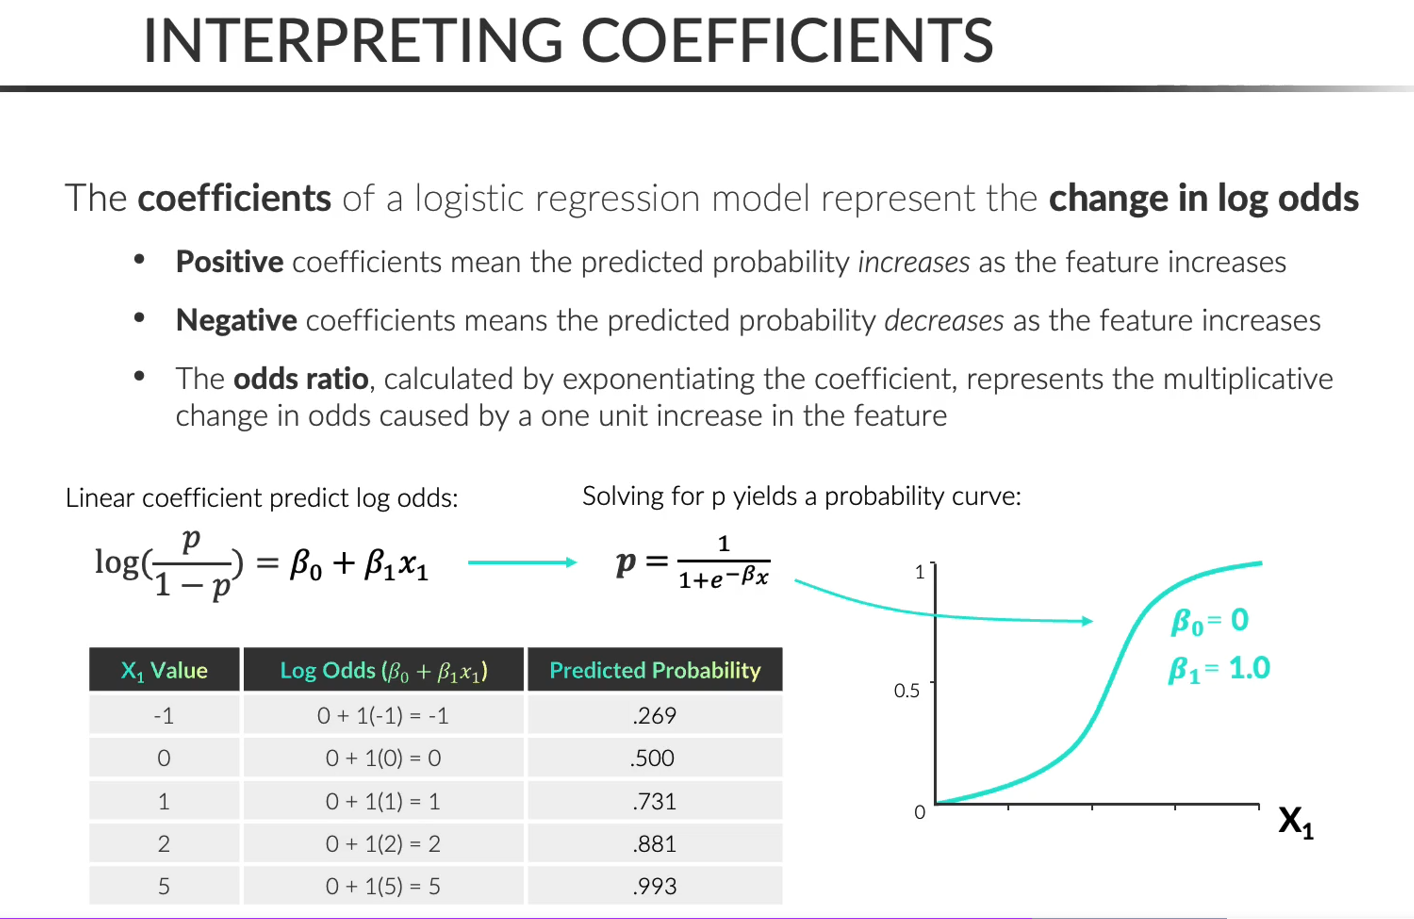